In [11]:
using LinearAlgebra
using Distributions

using LaTeXStrings
using Printf
using FileIO
import JLD2

In [12]:
#using Plots
#using StatsPlots

In [13]:
using DataFrames


In [14]:
using Revise
using Newtrinos
using Newtrinos.osc

In [15]:
using Pkg
Pkg.status() 

Status `~/.julia/environments/myenv/Project.toml`
⌃ [336ed68f] CSV v0.10.15
⌅ [13f3f980] CairoMakie v0.13.6
  [35d6a980] ColorSchemes v3.31.0
  [5ae59095] Colors v0.13.1
⌃ [7073ff75] IJulia v1.27.0
  [6a3955dd] ImageFiltering v0.7.12
⌅ [a98d9a8b] Interpolations v0.15.1
  [fa1605e6] MeasureBase v0.14.13
  [5b289081] Newtrinos v0.0.1 `~/Newtrinos.jl`
⌃ [91a5bcdd] Plots v1.40.17
  [92933f4c] ProgressMeter v1.11.0
⌃ [295af30f] Revise v3.7.5
⌅ [f2b01f46] Roots v2.2.10
  [efcf1570] Setfield v1.1.2
⌃ [0c5d862f] Symbolics v6.57.0
⌃ [3cd96dde] UnROOT v0.8.20
Info Packages marked with ⌃ and ⌅ have new versions available. Those with ⌃ may be upgradable, but those with ⌅ are restricted by compatibility constraints from upgrading. To see why use `status --outdated`


In [16]:
osc_cfg = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.NNM(),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
    )

osc = Newtrinos.osc.configure(osc_cfg)

Newtrinos.osc.Osc(OscillationConfig{NNM, SI, Basic, Newtrinos.osc.All, FullMatrix}(NNM(ThreeFlavour(:NO)), SI(), Basic(), Newtrinos.osc.All(), FullMatrix()), (m₀ = 0.01, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761, δCP = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, N = 20.0, r = 1.0, η = 1.05), (m₀ = LogUniform{Float64}(a=1.0e-6, b=0.1), θ₁₂ = Uniform{Float64}(a=0.4205343352839651, b=0.7853981633974483), θ₁₃ = Uniform{Float64}(a=0.1, b=0.2), θ₂₃ = Uniform{Float64}(a=0.5235987755982988, b=1.0471975511965976), δCP = Uniform{Float64}(a=0.0, b=6.283185307179586), Δm²₂₁ = Uniform{Float64}(a=6.5e-5, b=9.0e-5), Δm²₃₁ = Uniform{Float64}(a=0.002, b=0.003), N = DiscreteUniform(a=2, b=5000), r = LogUniform{Float64}(a=1.0e-6, b=1.0), η = Uniform{Float64}(a=1.01, b=100.0)), Newtrinos.osc.var"#get_Nnaturalness#55"(), Newtrinos.osc.var"#osc_prob#47"{Newtrinos.osc.var"#osc_prob#45#48"{OscillationConfig{NNM, SI, Basic, Newtrinos.osc.All, FullMatrix}, Newtrinos.o

In [17]:

atm_flux = Newtrinos.atm_flux.configure()
earth_layers = Newtrinos.earth_layers.configure()
xsec=Newtrinos.xsec.configure()
physics = (; osc, atm_flux, earth_layers, xsec);

In [18]:
experiments = (

    nova = Newtrinos.nova.configure(physics),
);

[ Info: Loading NOvA data


=== LOADING NUE DATA ===
=== LOADING NUEBAR DATA ===
=== LOADING NUMU DATA ===


In [19]:
p = Newtrinos.get_params(experiments)

(N = 20.0, m₀ = 0.01, nc_norm = 1.0, nova_norm = 1.0, nutau_cc_norm = 1.0, r = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, δCP = 1.0, η = 1.05, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761)

┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie ~/.julia/packages/Makie/dYDv2/src/scenes.jl:238


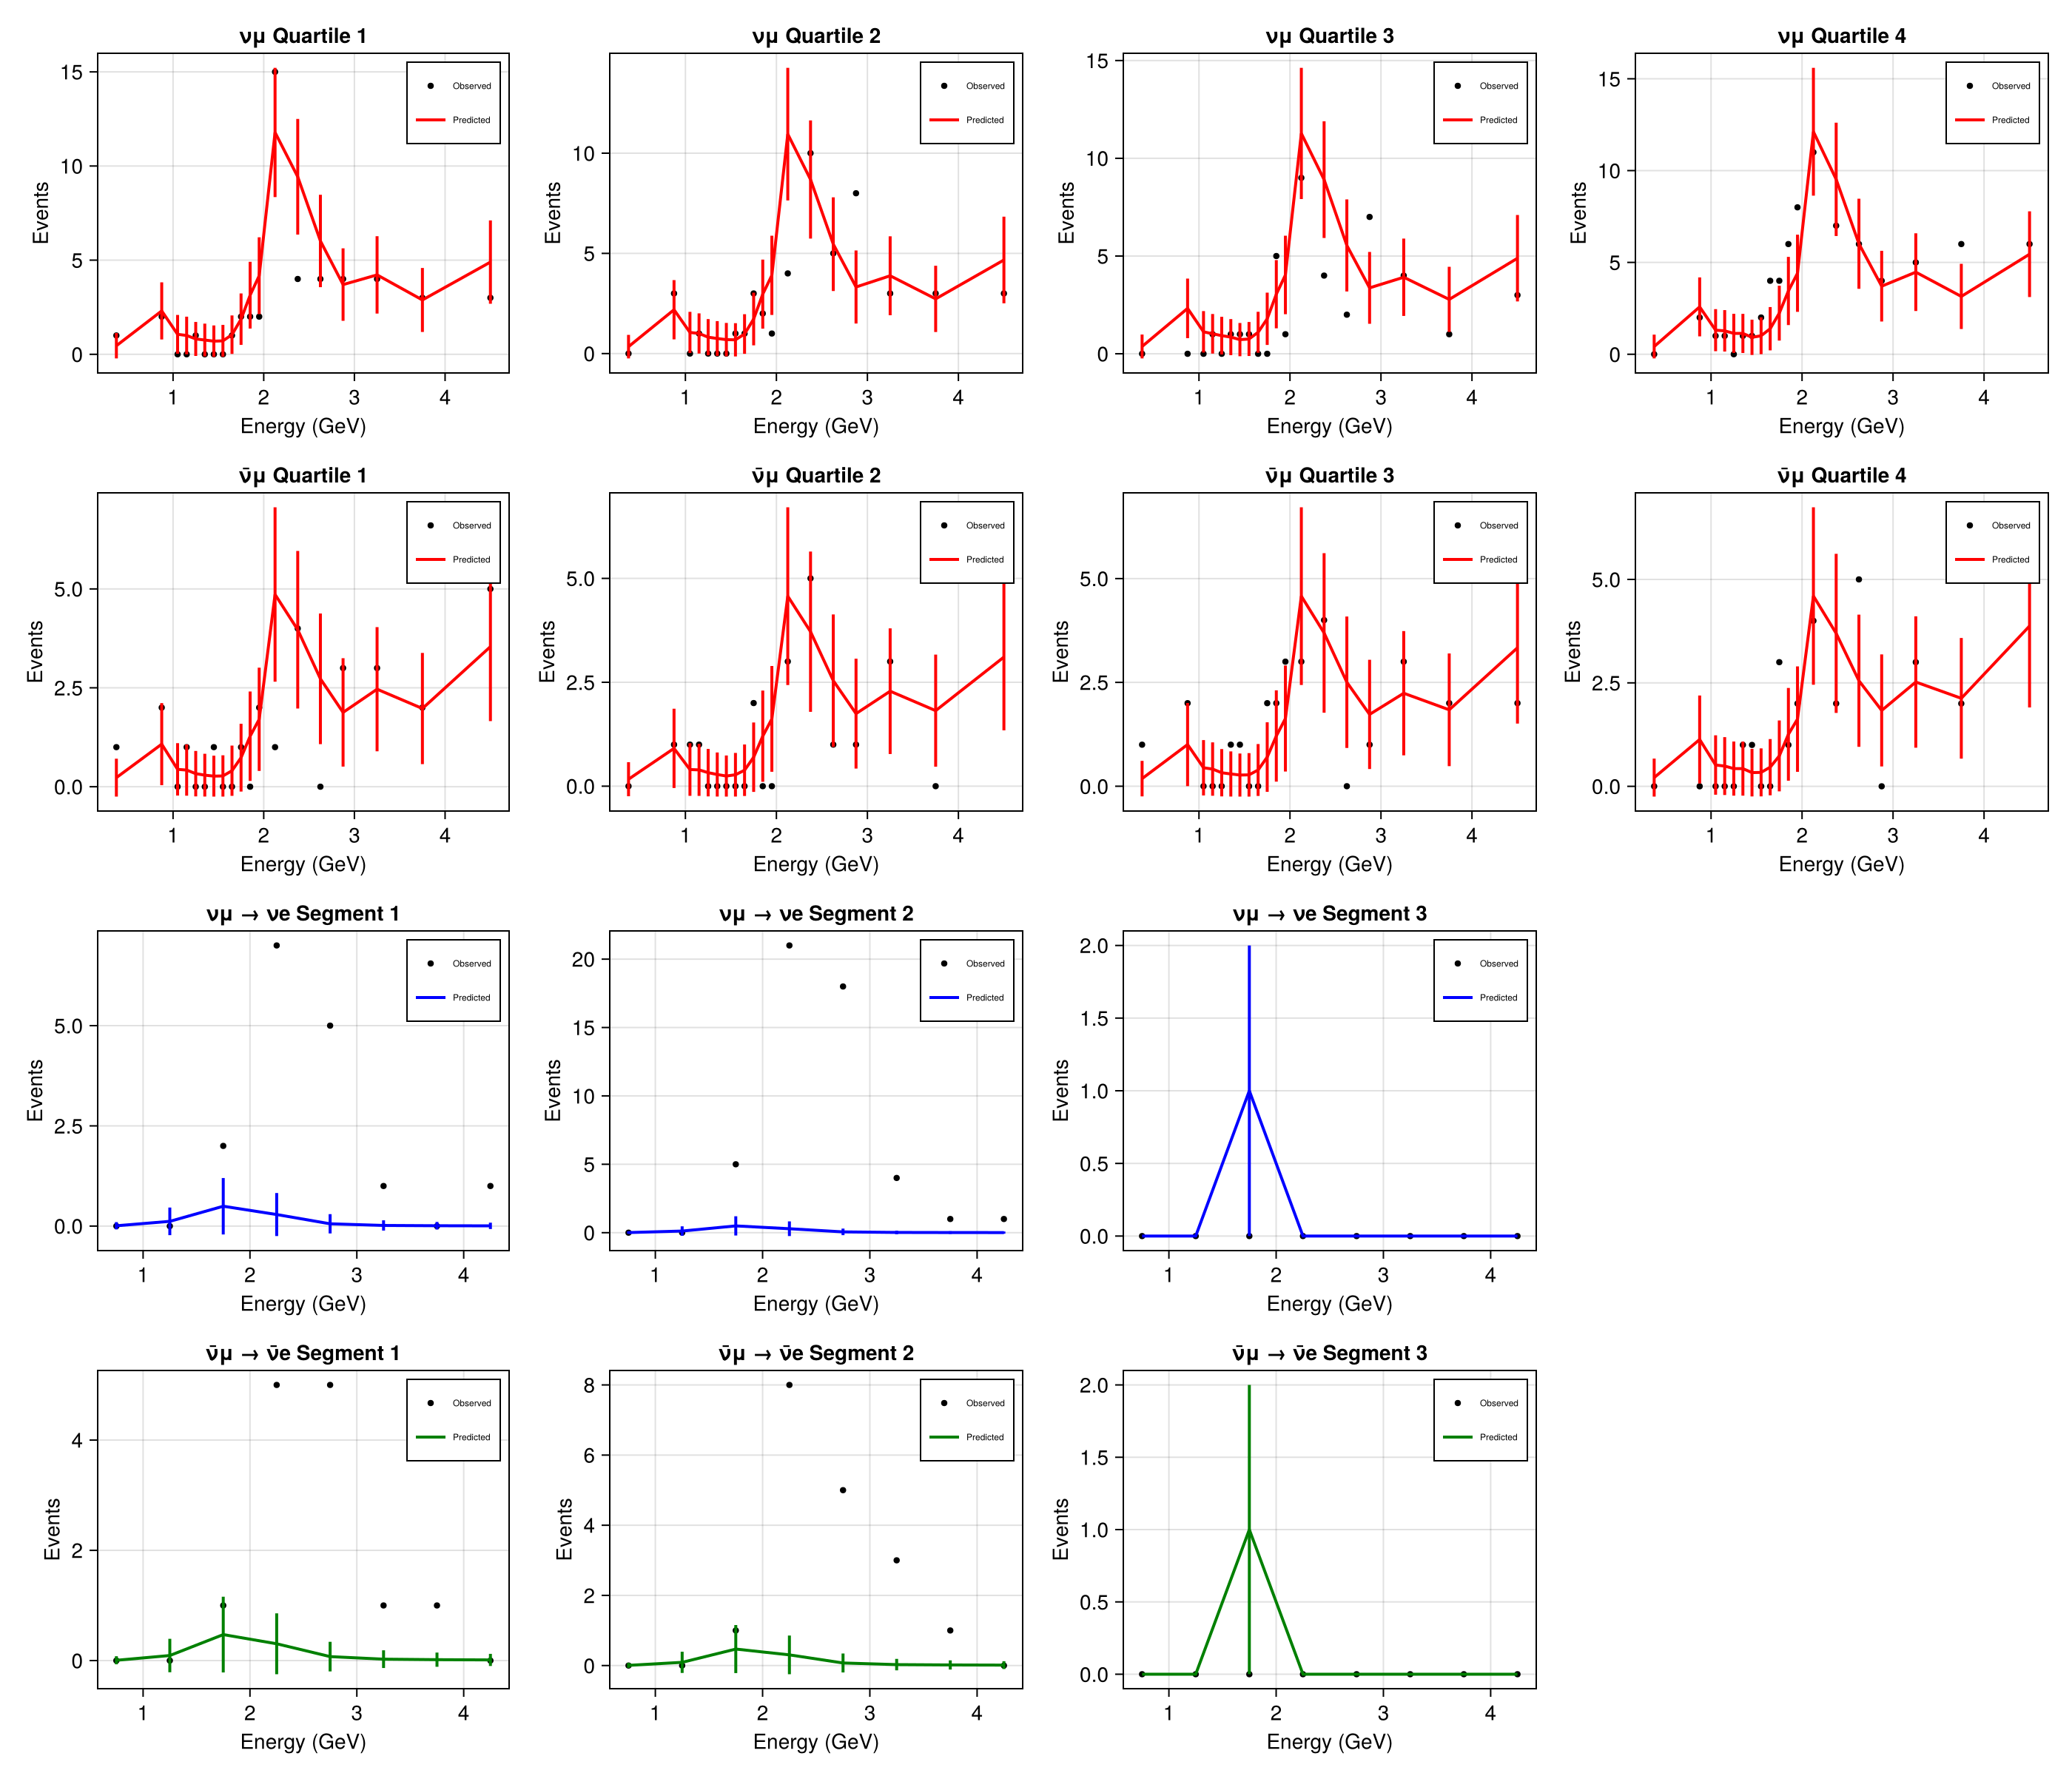

In [20]:
img = experiments.nova.plot(p)
display("image/png", img)
#save("/home/sofialon/Newtrinos.jl/profiled plot/nova/nova_data_NND.png", img)

In [16]:

all_priors = Newtrinos.get_priors(experiments)


vars_to_scan = ( θ₂₃=31,  Δm²₃₁ =31)  

modified_priors = (
   #N =all_priors.N, 
   m₀= all_priors.m₀,
  # r = all_priors.r,
    
   
  

    Δm²₂₁ = p.Δm²₂₁,  
    Δm²₃₁ = all_priors.Δm²₃₁ , 
    δCP =  all_priors.δCP,    
    θ₁₂ = p.θ₁₂,    
    θ₁₃= p.θ₁₃,       
    θ₂₃ = all_priors.θ₂₃   
    

)


(m₀ = LogUniform{Float64}(a=1.0e-6, b=0.1), Δm²₂₁ = 7.53e-5, Δm²₃₁ = Uniform{Float64}(a=0.002, b=0.003), δCP = Uniform{Float64}(a=0.0, b=6.283185307179586), θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = Uniform{Float64}(a=0.5235987755982988, b=1.0471975511965976))

In [17]:

likelihood = Newtrinos.generate_likelihood(experiments);


In [18]:

result = Newtrinos.scan(likelihood, modified_priors, vars_to_scan, p)

Number of threads: 4
Total points to compute: 961


Progress: 100%|█████████████████████████████████████████| Time: 0:01:28

TIMING STATISTICS:
  Min time per point: 0.2 ms


  Max time per point: 1180.0 ms
  Mean time per point: 92.1 ms
  Median time per point: 54.7 ms
TOTAL TIME:
  Total seconds: 88.52
  Total minutes: 1.48


NewtrinosResult((θ₂₃ = [0.5235987755982988, 0.5410520681182421, 0.5585053606381853, 0.5759586531581287, 0.593411945678072, 0.6108652381980153, 0.6283185307179586, 0.6457718232379018, 0.6632251157578452, 0.6806784082777885  …  0.890117918517108, 0.9075712110370513, 0.9250245035569946, 0.9424777960769379, 0.9599310885968813, 0.9773843811168245, 0.9948376736367678, 1.012290966156711, 1.0297442586766543, 1.0471975511965976], Δm²₃₁ = [0.002, 0.002033333333333333, 0.0020666666666666667, 0.0021, 0.0021333333333333334, 0.0021666666666666666, 0.0022, 0.0022333333333333333, 0.002266666666666667, 0.0023  …  0.0027, 0.0027333333333333333, 0.002766666666666667, 0.0028, 0.0028333333333333335, 0.0028666666666666667, 0.0029000000000000002, 0.0029333333333333334, 0.002966666666666667, 0.003]), (N = [20.0 20.0 … 20.0 20.0; 20.0 20.0 … 20.0 20.0; … ; 20.0 20.0 … 20.0 20.0; 20.0 20.0 … 20.0 20.0], m₀ = [0.01 0.01 … 0.01 0.01; 0.01 0.01 … 0.01 0.01; … ; 0.01 0.01 … 0.01 0.01; 0.01 0.01 … 0.01 0.01], nc_nor

In [96]:
#likelihood = Newtrinos.generate_likelihood(experiments);
#result = Newtrinos.scan(likelihood, Newtrinos.get_priors(experiments), (θ₁₃=31, Δm²₃₁=31), p)
#result = Newtrinos.profile(likelihood,  Newtrinos.get_priors(experiments), (r=31, m₀=31), p; gradient_map=false)

In [97]:
#JLD2.@save "scan_nova_rdelta_NNM.jld2" result

In [19]:
using CairoMakie

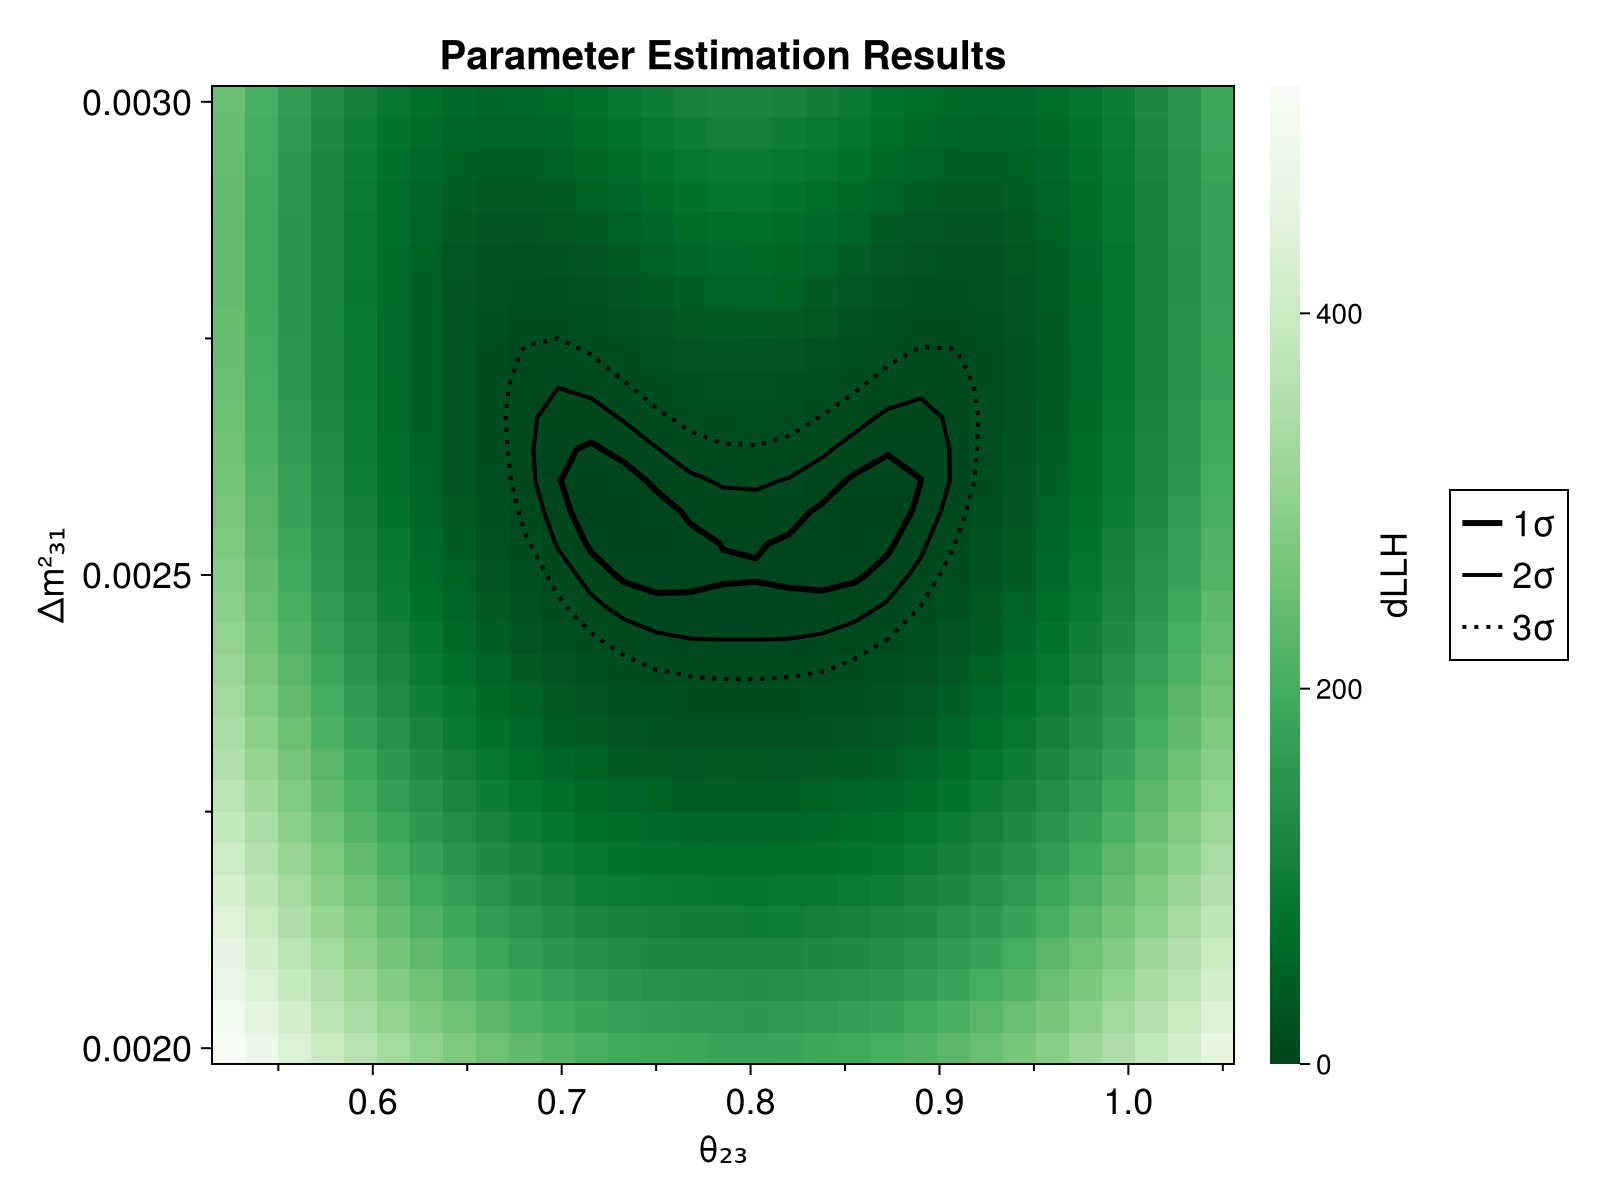

In [20]:
img = CairoMakie.plot(result)
display("image/png", img)
#save("/home/sofialon/Newtrinos.jl/natural plot/nova/nova_rdelta_NNM.png", img)


Oscillations


In [109]:

# STANDARD MODEL
E_range = range(0.5,10, length=1000) 
L=810
L_vec = [L]

osc_cfg_SM = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.ThreeFlavour(),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
    )

osc_SM = Newtrinos.osc.configure(osc_cfg_SM)
 

atm_flux = Newtrinos.atm_flux.configure()
earth_layers = Newtrinos.earth_layers.configure()
xsec_SM = Newtrinos.xsec.configure()

physics_SM = (; osc=osc_SM, atm_flux, earth_layers, xsec=xsec_SM);


experiments_SM = (

    nova = Newtrinos.nova.configure(physics_SM),
);

p_SM = Newtrinos.get_params(experiments_SM)

osc_prob_SM = Newtrinos.osc.get_osc_prob(osc_cfg_SM)


probab_SM = osc_prob_SM(collect(E_range), L_vec, p; anti=true)

[ Info: Loading NOvA data


=== LOADING NUE DATA ===
Using :fN for neutrino data
Found MC directory: prediction_components_nue_fhc
Using :fN field, length: 23
Created: Signal1, Signal2, Signal3
Using :fN field, length: 23
Created: Wrong_sign_bkg1, Wrong_sign_bkg2, Wrong_sign_bkg3
Using :fN field, length: 23
Created: Beam_nue_bkg1, Beam_nue_bkg2, Beam_nue_bkg3
Using :fN field, length: 23
Created: NC_bkg1, NC_bkg2, NC_bkg3
Using :fN field, length: 23
Created: NumuCC_bkg1, NumuCC_bkg2, NumuCC_bkg3
Using :fN field, length: 23
Created: TauCC_bkg1, TauCC_bkg2, TauCC_bkg3
Using :fN field, length: 23
Created: Cosmic_bkg1, Cosmic_bkg2, Cosmic_bkg3
Using :fN field, length: 23
Created: Total_pred1, Total_pred2, Total_pred3
=== LOADING NUEBAR DATA ===
Using :fN for antineutrino data
Found MC directory: prediction_components_nue_rhc
Using :fN field, length: 23
Created: Signal1, Signal2, Signal3
Using :fN field, length: 23
Created: Wrong_sign_bkg1, Wrong_sign_bkg2, Wrong_sign_bkg3
Using :fN field, length: 23
Created: Beam_nue_

1000×1×3×3 Array{Float64, 4}:
[:, :, 1, 1] =
 0.9069452157631035
 0.9036651921584132
 0.9017080834473145
 0.9010216381353084
 0.9015154361137327
 0.9030729357154513
 0.9055616190842493
 0.9088412532267084
 0.9127703944258465
 0.9172113249659739
 0.9220336379172318
 0.927116689431564
 0.9323511271574965
 ⋮
 0.9947446253797604
 0.9947544955908768
 0.9947643382346977
 0.994774153412954
 0.9947839412269126
 0.9947937017773776
 0.9948034351646939
 0.9948131414887489
 0.9948228208489751
 0.9948324733443533
 0.9948420990734134
 0.9948516981342393

[:, :, 2, 1] =
 0.014385870713263214
 0.01730443449974073
 0.020041776439870772
 0.02250521580086591
 0.024629481163403265
 0.026373723782354398
 0.027718032378655753
 0.028659808561209046
 0.02921024958386834
 0.029391096038134133
 0.029231734313094154
 0.028766694134083944
 0.028033546864435
 ⋮
 0.0031483971670383695
 0.0031425975176499654
 0.003136813729496944
 0.0031310457453860474
 0.003125293508378625
 0.003119556961789251
 0.00311383604918444

In [111]:
# NNATURALNESS WITH DIFFERENT N 


osc_prob = Newtrinos.osc.get_osc_prob(osc_cfg)

p= Newtrinos.get_params(experiments)
p_5 = merge(p, (N = ftype(5),))
p_10 = merge(p, (N = ftype(10),))
p_20 = merge(p, (N = ftype(20),))
p_50 = merge(p, (N = ftype(50),))

probab_5 = osc_prob(collect(E_range), L_vec, p_5; anti=false)
probab_10 = osc_prob(collect(E_range), L_vec, p_10; anti=false)
probab_20 = osc_prob(collect(E_range), L_vec, p_20; anti=false)
probab_50 = osc_prob(collect(E_range), L_vec, p_50; anti=false)

p_0 = merge(p, (r = ftype(1e-8),))
p_025 = merge(p,  (r = ftype(0.25),))
p_05 = merge(p,  (r = ftype(0.5),))
p_1 = merge(p,  (r = ftype(1),))


probab_0 = osc_prob(collect(E_range), L_vec, p_0; anti=false)
probab_025 = osc_prob(collect(E_range), L_vec, p_025; anti=false)
probab_05 = osc_prob(collect(E_range), L_vec, p_05; anti=false)
probab_1 = osc_prob(collect(E_range), L_vec, p_1; anti=false)


1000×1×60×60 Array{Float64, 4}:
[:, :, 1, 1] =
 0.9030289029549879
 0.8972683566008884
 0.8964489584336803
 0.8934402931292365
 0.8899321427676276
 0.8927408761278302
 0.8905498968540829
 0.8946565822033633
 0.8982979982979273
 0.9018208736614948
 0.9065518063492105
 0.9053336092035909
 0.9114483700387074
 ⋮
 0.9880557382864427
 0.9833602021632568
 0.9909138587028025
 0.9899244550419559
 0.990449220460022
 0.9875547095340752
 0.9891541573522478
 0.9906631376692526
 0.989700184983214
 0.9910220825598824
 0.9875567303758211
 0.9890462539920829

[:, :, 2, 1] =
 0.06461305601697741
 0.07167059774269746
 0.07720621206572441
 0.08087149337645246
 0.0830742797933755
 0.08517783637499615
 0.08477487818181936
 0.08498883347722105
 0.08369090729991277
 0.08055595699329708
 0.07804862684546564
 0.07421648923606851
 0.07020942480641379
 ⋮
 0.0034998247251111217
 0.0035452647381577535
 0.0035166599261741947
 0.0034822837039200994
 0.0033692406212445735
 0.0034480275485665127
 0.0036038590854518245


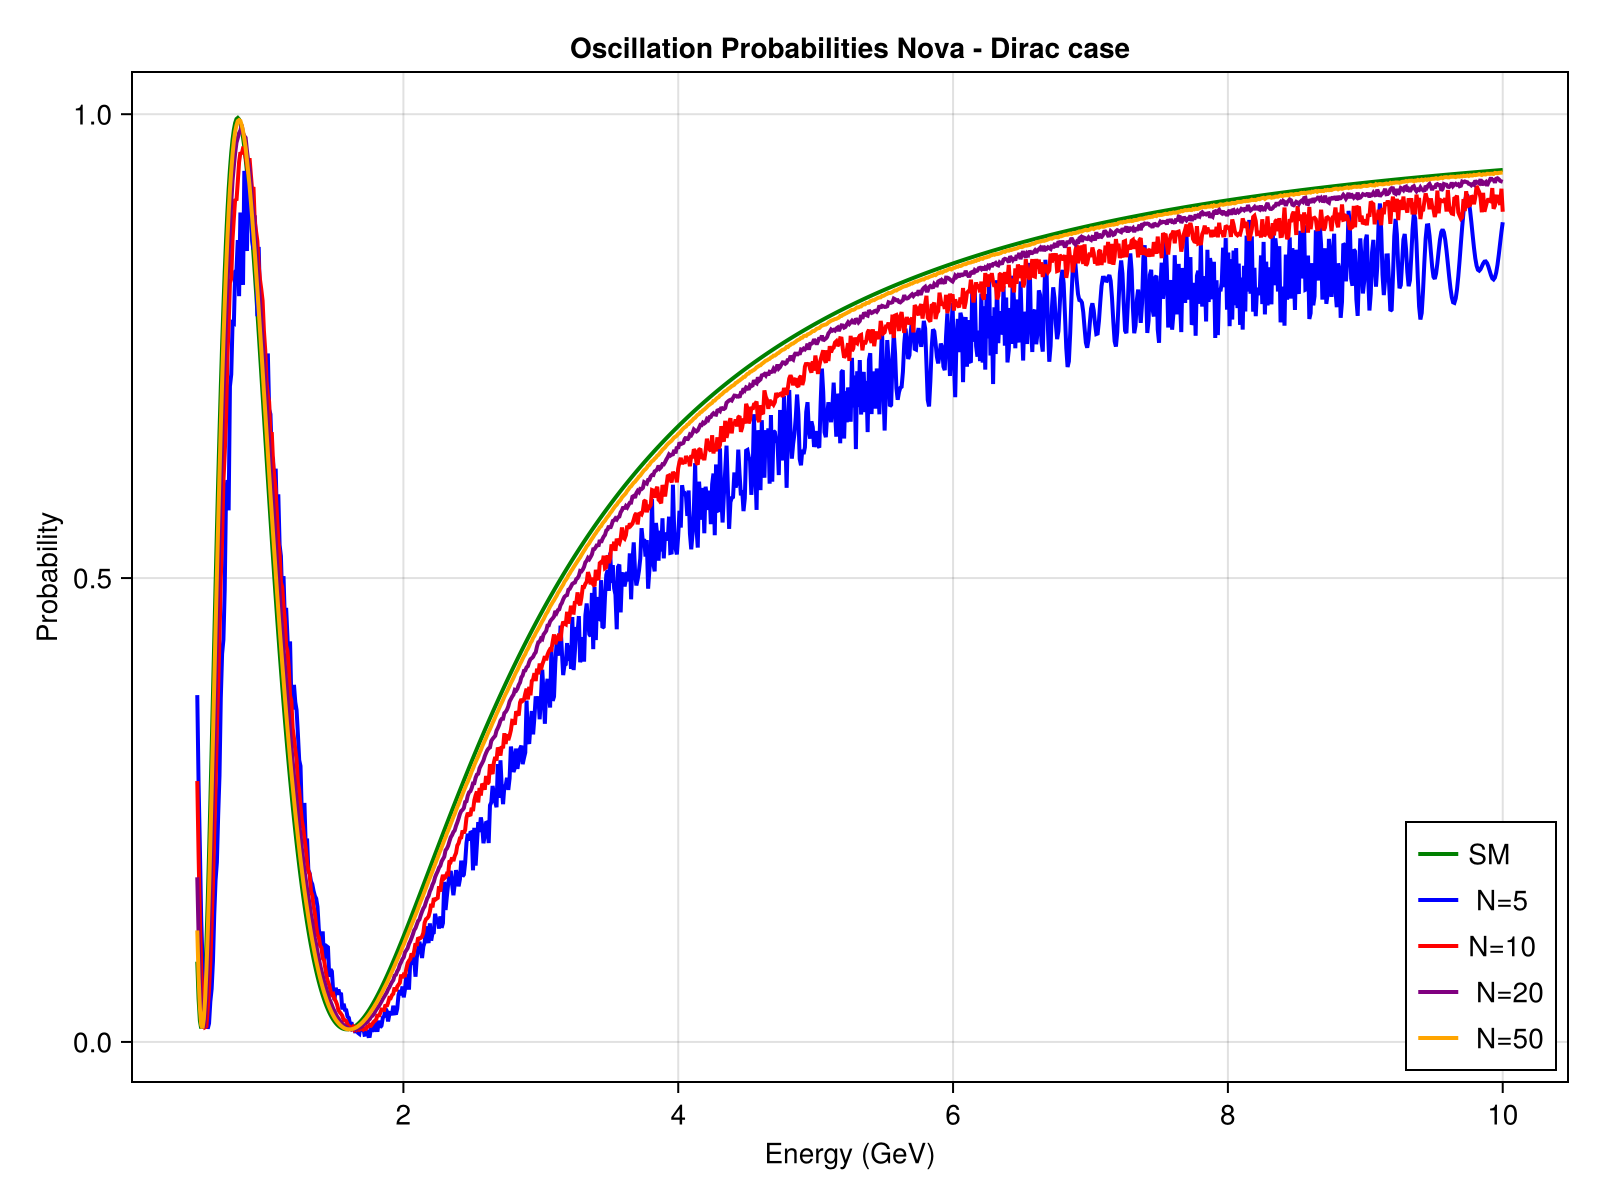

In [112]:

fig = Figure(size=(800, 600))
ax = Axis(fig[1,1], 
    xlabel = "Energy (GeV)",
    ylabel = "Probability", 
    title = "Oscillation Probabilities Nova - Dirac case"
)

# Plot the lines
lines!(ax, E_range, probab_SM[:, 1, 2,2], label="SM", linewidth=2, color=:green)
lines!(ax, E_range, probab_5[:, 1, 2,2], label=" N=5", linewidth=2, color=:blue)
lines!(ax, E_range, probab_10[:, 1, 2,2], label="N=10", linewidth=2, color=:red)
lines!(ax, E_range, probab_20[:, 1, 2,2], label=" N=20", linewidth=2, color=:purple)
lines!(ax, E_range, probab_50[:, 1, 2,2], label=" N=50", linewidth=2, color=:orange)

# Add legend and set limits
axislegend(ax, position=:rb)
#save("/home/sofialon/Newtrinos.jl/natural plot/nova/osc_nova_N_dirac.png", fig)


fig

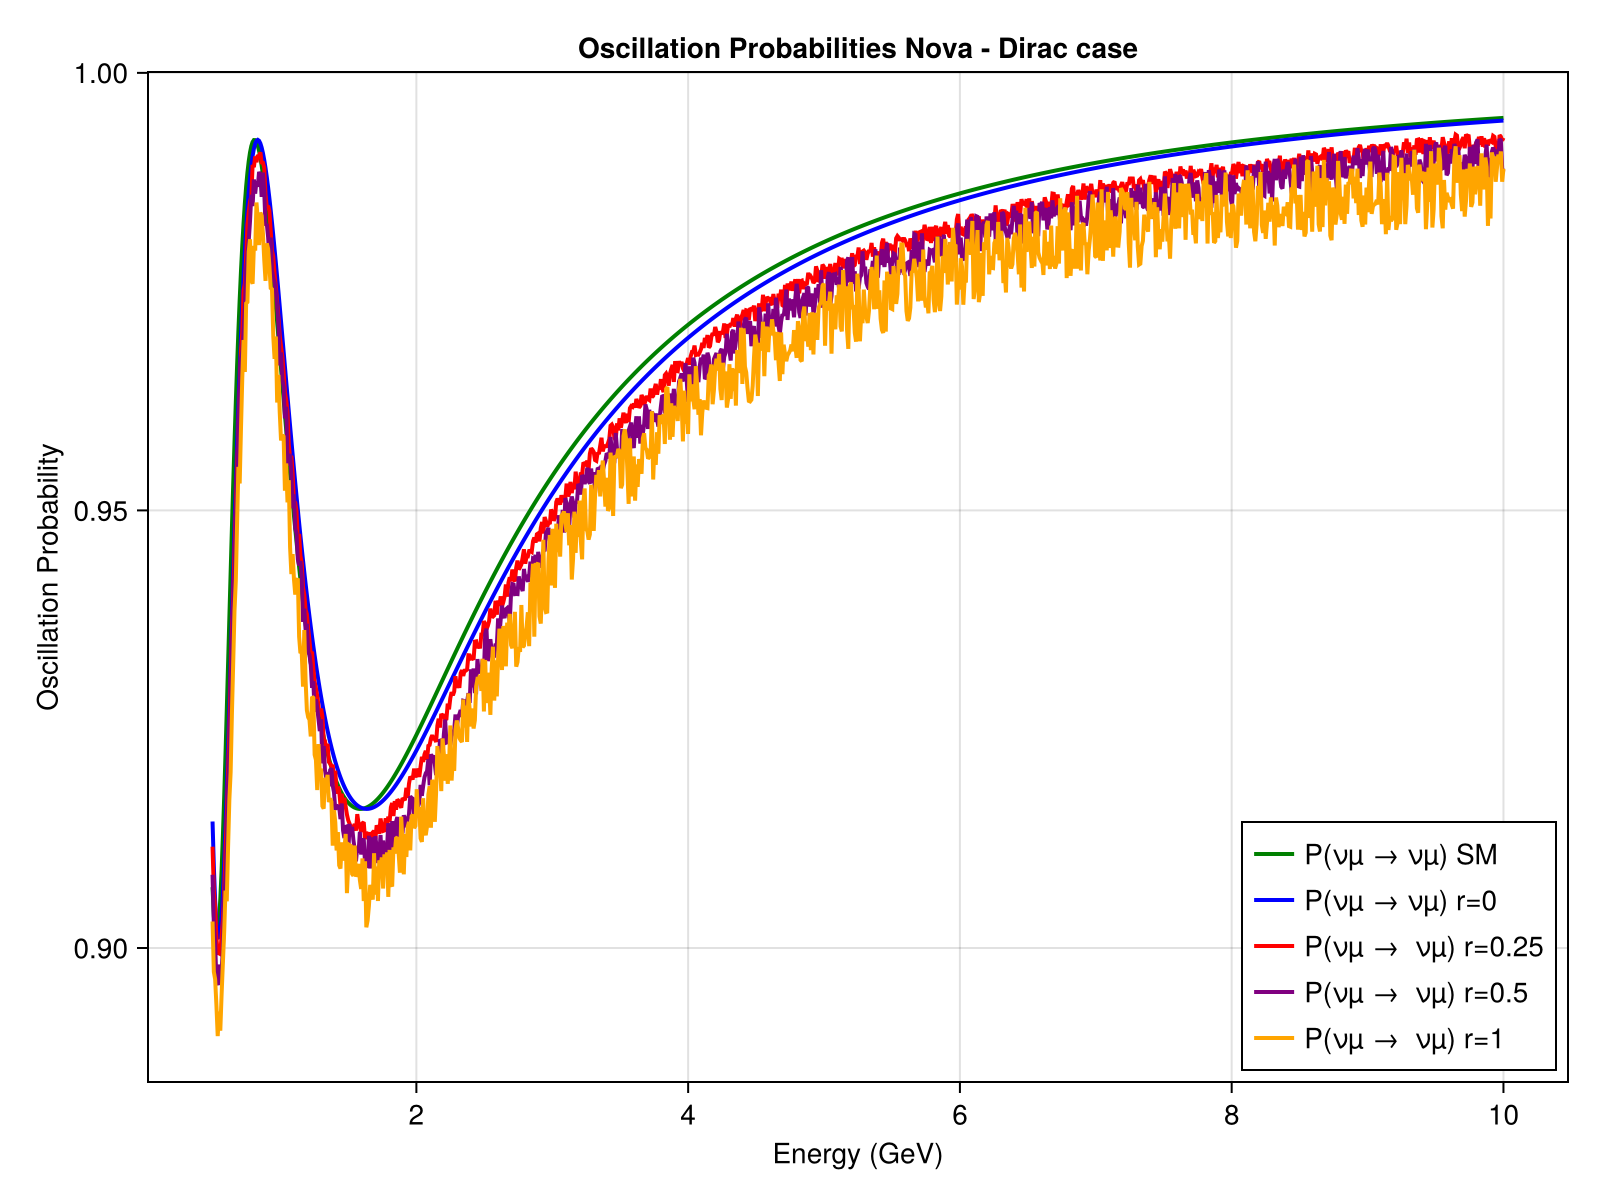

In [113]:

fig = Figure(size=(800, 600))
ax = Axis(fig[1,1], 
    xlabel = "Energy (GeV)",
    ylabel = "Oscillation Probability", 
    title = "Oscillation Probabilities Nova - Dirac case"
)

# Plot the lines
lines!(ax, E_range, probab_SM[:, 1, 1, 1], label="P(νµ → νµ) SM", linewidth=2, color=:green)
lines!(ax, E_range, probab_0[:, 1, 1, 1], label="P(νµ → νµ) r=0", linewidth=2, color=:blue)
lines!(ax, E_range, probab_025[:, 1, 1, 1], label="P(νµ →  νµ) r=0.25", linewidth=2, color=:red)
lines!(ax, E_range, probab_05[:, 1, 1, 1], label="P(νµ →  νµ) r=0.5", linewidth=2, color=:purple)
lines!(ax, E_range, probab_1[:, 1, 1, 1], label="P(νµ →  νµ) r=1", linewidth=2, color=:orange)

# Add legend and set limits
axislegend(ax, position=:rb)
#save("/home/sofialon/Newtrinos.jl/natural plot/nova/osc_nova_r_dirac.png", fig)

fig

In [114]:
all_priors = Newtrinos.get_priors(experiments)


vars_to_scan = (r=31, N=31)  
#vars_to_scan=(m₀=31,   N=31)

modified_priors = (
    N = DiscreteUniform(2, 50),
    m₀ =LogUniform(1e-4, 0.1),
    r =Uniform(1e-8, 1.0),#all_priors.r, 
   
    
   
  

    Δm²₂₁ = p.Δm²₂₁,  
    Δm²₃₁ =p.Δm²₃₁ , 
    δCP = p.δCP,  
    
    η=p.η,
    θ₁₂ = p.θ₁₂,    
    θ₁₃=p.θ₁₃,       
    θ₂₃ = p.θ₂₃   
    

)


(N = DiscreteUniform(a=2, b=50), m₀ = LogUniform{Float64}(a=0.0001, b=0.1), r = Uniform{Float64}(a=1.0e-8, b=1.0), Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, δCP = 1.0, η = 1.05, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761)

In [115]:

likelihood = Newtrinos.generate_likelihood(experiments);

In [116]:
result = Newtrinos.scan(likelihood, modified_priors, vars_to_scan, p)

Number of threads: 4
Total points to compute: 961


Progress: 100%|█████████████████████████████████████████| Time: 0:03:18


TIMING STATISTICS:
  Min time per point: 0.0 ms
  Max time per point: 2919.4 ms
  Mean time per point: 211.3 ms
  Median time per point: 111.1 ms
TOTAL TIME:
  Total seconds: 203.09
  Total minutes: 3.38


NewtrinosResult((r = [1.0e-8, 0.033333343, 0.066666676, 0.100000009, 0.133333342, 0.166666675, 0.200000008, 0.233333341, 0.266666674, 0.30000000699999996  …  0.700000003, 0.733333336, 0.766666669, 0.8000000020000001, 0.8333333350000001, 0.866666668, 0.900000001, 0.9333333340000001, 0.966666667, 1.0], N = [2, 3, 5, 6, 8, 10, 11, 13, 15, 16  …  36, 37, 39, 41, 42, 44, 46, 47, 49, 50]), (m₀ = [0.01 0.01 … 0.01 0.01; 0.01 0.01 … 0.01 0.01; … ; 0.01 0.01 … 0.01 0.01; 0.01 0.01 … 0.01 0.01], nc_norm = [1.0 1.0 … 1.0 1.0; 1.0 1.0 … 1.0 1.0; … ; 1.0 1.0 … 1.0 1.0; 1.0 1.0 … 1.0 1.0], nutau_cc_norm = [1.0 1.0 … 1.0 1.0; 1.0 1.0 … 1.0 1.0; … ; 1.0 1.0 … 1.0 1.0; 1.0 1.0 … 1.0 1.0], Δm²₂₁ = [7.53e-5 7.53e-5 … 7.53e-5 7.53e-5; 7.53e-5 7.53e-5 … 7.53e-5 7.53e-5; … ; 7.53e-5 7.53e-5 … 7.53e-5 7.53e-5; 7.53e-5 7.53e-5 … 7.53e-5 7.53e-5], Δm²₃₁ = [0.0024752999999999997 0.0024752999999999997 … 0.0024752999999999997 0.0024752999999999997; 0.0024752999999999997 0.0024752999999999997 … 0.00247529999999999

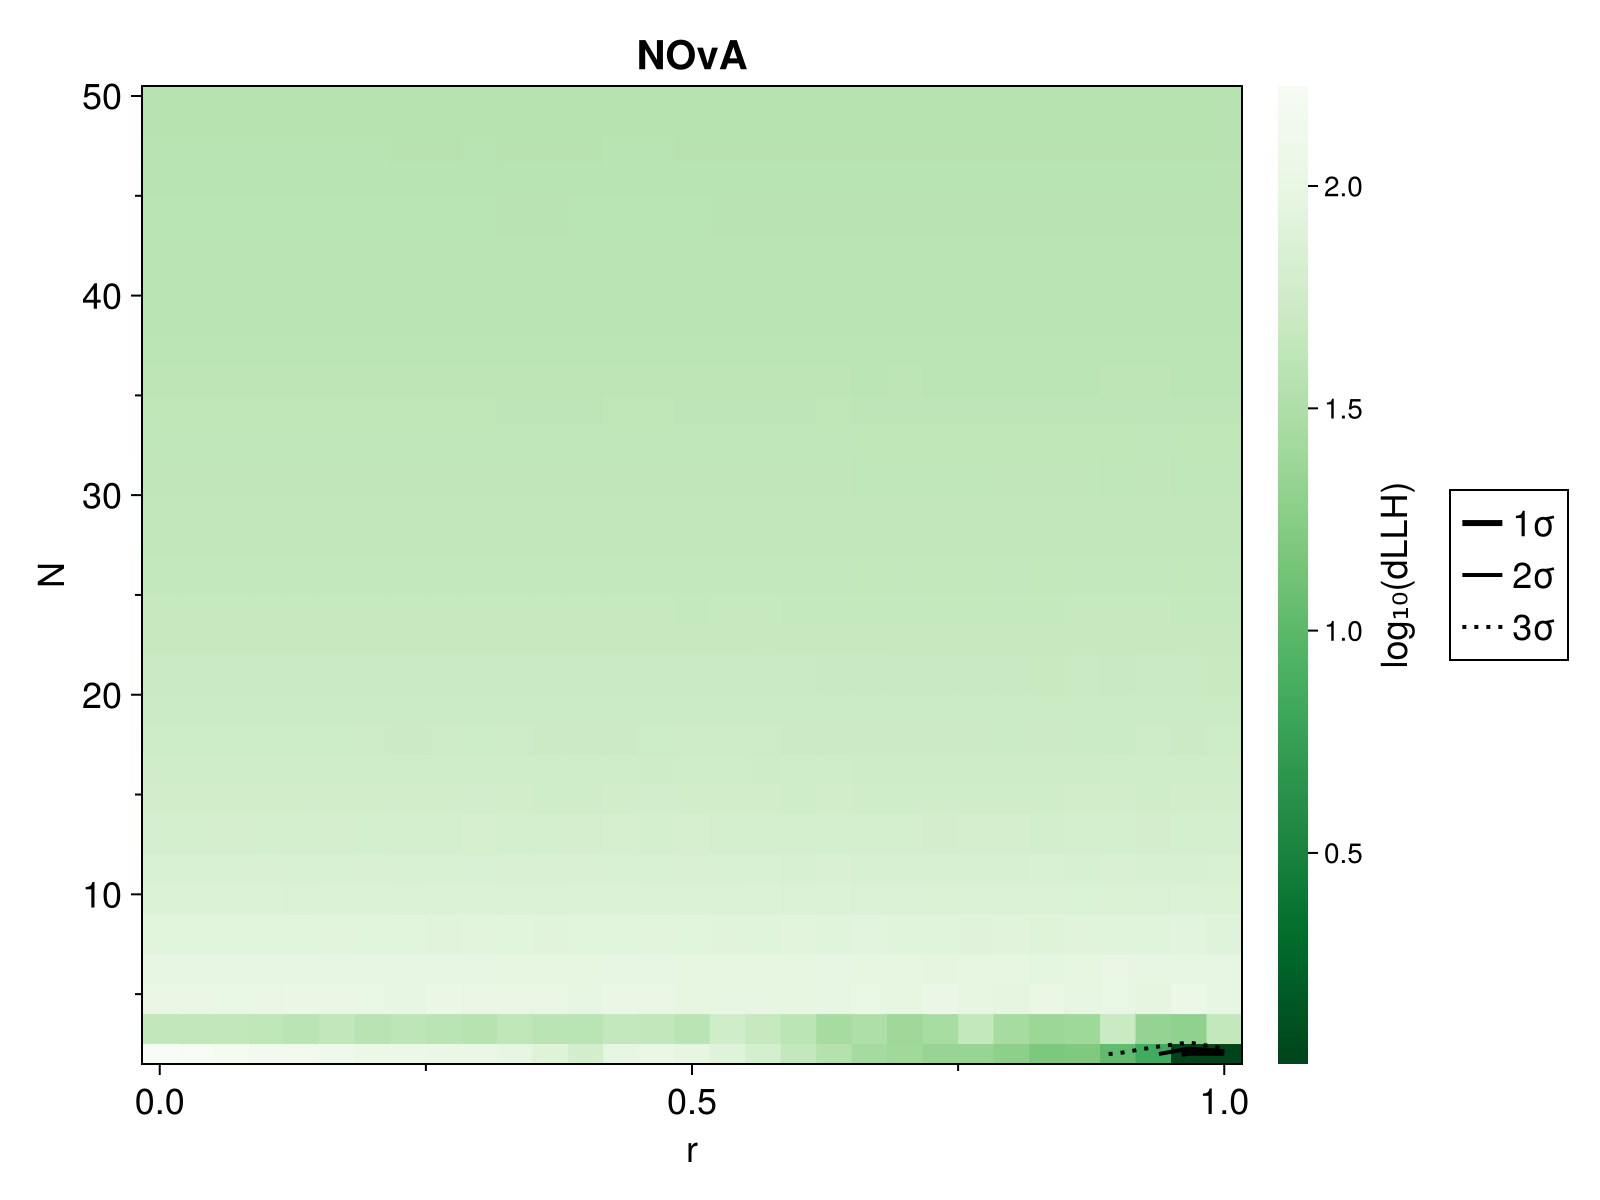

In [117]:
img = CairoMakie.plot(result; title="NOvA", log=0, mass=0, log_colormap=true)
display("image/png", img)